# 01

In [1]:
import os
PROJECT_ROOT = "/home/dotamthuc-3090/Projects/ViewSynthesis/"
print("PROJECT_ROOT:", PROJECT_ROOT)

import sys
lib_decompre = "/home/dotamthuc-3090/Projects/ViewSynthesis/Differentiable3DPC-Decompression-and-Rendering"
sys.path.insert(0, lib_decompre)

lib_svraster = "/home/dotamthuc-3090/Projects/ViewSynthesis/svraster"
sys.path.insert(0, lib_svraster)

import time
import itertools
import numpy as np
import torch
from matplotlib.pylab import plt

from libs.dataloader.View import View, ViewCreator
from libs.dataloader.Scene import Scene
from libs.multiscale_splats_coder.modelv00 import *
from libs.entropy_coder import rlgr
from libs.baseline import raht, pointcloud3d

import decompress_render

from src.dataloader.data_pack import DataPack
from src.sparse_voxel_model import SparseVoxelModel
from src.config import cfg, update_argparser, update_config


torch.set_printoptions(
    precision=4,
    sci_mode=False,
    threshold=10000,    # Print the full array if it has fewer than 10000 elements
    linewidth=1000       # Number of characters per line
)
np.set_printoptions(
    precision=4,        # Number of digits of precision for floating point output
    suppress=False,      # Suppress scientific notation
    threshold=10000,    # Print the full array if it has fewer than 10000 elements
    linewidth=1000       # Number of characters per line
)

def rgb2shzero(x):
    return (x - 0.5) / 0.28209479177387814

def shzero2rgb(x):
    return x * 0.28209479177387814 + 0.5

PROJECT_ROOT: /home/dotamthuc-3090/Projects/ViewSynthesis/


## Test

In [2]:
def rgb2shzero(x):
    return (x - 0.5) / 0.28209479177387814

def shzero2rgb(x):
    return x * 0.28209479177387814 + 0.5

In [3]:

ref_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt")

In [4]:
voxel_morton_code = ref_denfield.voxel_morton_code.detach().cpu().numpy()
voxel_position = ref_denfield.voxel_position.detach().cpu().numpy()
voxel_size = ref_denfield.voxel_size.detach().cpu().numpy()
voxel2corner = ref_denfield.voxel2corner.detach().cpu().numpy()
corner_geo_params = ref_denfield.corner_geo_params.detach().cpu().numpy()
num_voxels = ref_denfield.num_voxels
voxel_attribute_field = ref_denfield.voxel_attribute_field.detach().cpu().numpy()

order = np.argsort(voxel_morton_code)



In [5]:
index = np.arange(0, voxel_morton_code.shape[0]).astype(np.int32)
order = np.argsort(voxel_morton_code[:, 0])

index = index[order]
voxel_morton_code_ordered = voxel_morton_code[order, 0]
voxel_size_ordered = voxel_size[order, 0]
voxel_attribute_field_ordered = voxel_attribute_field[order, :]



In [6]:

binlevel, coeff_binlevel = raht.RahtPrologue(voxel_morton_code_ordered, mass=voxel_size_ordered)
transformed_attributes = raht.Raht(binlevel, shzero2rgb(voxel_attribute_field_ordered))
decoded_attributes_ordered = rgb2shzero(raht.InvRaht(binlevel, transformed_attributes))


In [7]:
decoded_attributes = np.zeros_like(decoded_attributes_ordered)
decoded_attributes[index] = decoded_attributes_ordered

In [8]:
decoded_attributes

array([[0.3071, 0.2068, 0.    ],
       [0.1402, 0.219 , 0.0356],
       [0.5224, 0.5292, 0.5128],
       ...,
       [0.6142, 0.4353, 0.1025],
       [0.6088, 0.5194, 0.6751],
       [0.3867, 0.1792, 0.    ]], dtype=float32)

In [10]:
source_path = "/home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen/"
scene_dataset = Scene(
    source_path, image_dir_name="images",
    res_downscale=8.0, res_width=0,
    encoder_view_every=20
)

train_views = scene_dataset.get_train_views()
test_views = scene_dataset.get_encoder_views()
len(train_views), len(test_views)


Read dataset in COLMAP format.
Done reading and creating views: 279 train views and 14 encoding views


(279, 14)

In [11]:


def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

decoded_attributes_tensor = torch.tensor(decoded_attributes, device="cuda")
list_mse = []
for view in train_views:
    tensor_img = ref_denfield.apply_phi_with_F(decoded_attributes_tensor, view).detach()
    rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    tensor_img_target = ref_denfield.apply_phi(view).detach()
    img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    mse = np.square(img_target/255 - rendered_img/255).mean()
    list_mse.append(mse)

psnr = -10 * np.log10(np.mean(list_mse))
print(f"psnr = {psnr}")

psnr = 85.77477918645066


## RD curve

In [2]:
source_path = "/home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen/"
scene_dataset = Scene(
    source_path, image_dir_name="images",
    res_downscale=8.0, res_width=0,
    encoder_view_every=20
)

train_views = scene_dataset.get_train_views()
test_views = scene_dataset.get_encoder_views()
len(train_views), len(test_views)


Read dataset in COLMAP format.
Done reading and creating views: 279 train views and 14 encoding views


(279, 14)

In [3]:
ref_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt")

####
voxel_morton_code = ref_denfield.voxel_morton_code.detach().cpu().numpy()
voxel_position = ref_denfield.voxel_position.detach().cpu().numpy()
voxel_size = ref_denfield.voxel_size.detach().cpu().numpy()
voxel2corner = ref_denfield.voxel2corner.detach().cpu().numpy()
corner_geo_params = ref_denfield.corner_geo_params.detach().cpu().numpy()
num_voxels = ref_denfield.num_voxels
voxel_attribute_field = ref_denfield.voxel_attribute_field.detach().cpu().numpy()

####
index = np.arange(0, voxel_morton_code.shape[0]).astype(np.int32)
order = np.argsort(voxel_morton_code[:, 0])

index = index[order]
voxel_morton_code_ordered = voxel_morton_code[order, 0]
voxel_size_ordered = voxel_size[order, 0]
voxel_attribute_field_ordered = voxel_attribute_field[order, :]


In [4]:
stepsizes = np.array([8, 16, 32, 64, 128, 256]) / 255
dist = np.zeros(len(stepsizes))
psnr = np.zeros(len(stepsizes))
rate = np.zeros(len(stepsizes))
for i, stepsize in enumerate(stepsizes):
    # Transform.
    binlevel, coeff_binlevel = raht.RahtPrologue(voxel_morton_code_ordered, mass=voxel_size_ordered)
    transformed_attributes = raht.Raht(binlevel, shzero2rgb(voxel_attribute_field_ordered))


    # Quantize transformed attributes to indices.
    quantization_indices = np.round(
        transformed_attributes / stepsize).astype(np.int32)

    # Entropy encode/decode.  (Here just copy.)
    decoded_morton_code = voxel_morton_code_ordered
    decoded_voxel_size_ordered = voxel_size_ordered
    decoded_quantization_indices = quantization_indices

    # De-quantize.
    decoded_transformed_attributes = decoded_quantization_indices * stepsize

    # Inverse transform.
    binlevel, coeff_binlevel = raht.RahtPrologue(decoded_morton_code, mass=decoded_voxel_size_ordered)
    decoded_attributes_ordered = rgb2shzero(raht.InvRaht(binlevel, decoded_transformed_attributes))

    # Reverse ordering
    decoded_attributes = np.zeros_like(decoded_attributes_ordered)
    decoded_attributes[index] = decoded_attributes_ordered


    # Entropy code.
    order = np.argsort(coeff_binlevel, kind="mergesort")
    rate[i] += rlgr.rlgr(quantization_indices[order][:, 0])
    rate[i] += rlgr.rlgr(quantization_indices[order][:, 1])
    rate[i] += rlgr.rlgr(quantization_indices[order][:, 2])

    # Distotion
    decoded_attributes_tensor = torch.tensor(decoded_attributes, device="cuda")
    list_mse = []
    for view in train_views:
        tensor_img = ref_denfield.apply_phi_with_F(decoded_attributes_tensor, view).detach()
        rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

        tensor_img_target = ref_denfield.apply_phi(view).detach()
        img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

        mse = np.square(img_target/255 - rendered_img/255).mean()
        list_mse.append(mse)
    
    dist[i] = np.mean(list_mse)
    psnr[i] = -10 * np.log10(dist[i])

    # Print details.
    print(f'stepsize={stepsize}, rate={rate[i]/num_voxels}, dist={dist[i]}, psnr={psnr[i]}')

stepsize=0.03137254901960784, rate=8.353376853376853, dist=0.0002662038730779188, psnr=35.74785630138084
stepsize=0.06274509803921569, rate=5.40993240993241, dist=0.0008675369466110645, psnr=30.61712020436076
stepsize=0.12549019607843137, rate=3.246752246752247, dist=0.0024327867072118318, psnr=26.138959658499168
stepsize=0.25098039215686274, rate=2.0128725128725127, dist=0.005570699220801966, psnr=22.540902898034155
stepsize=0.5019607843137255, rate=1.022087522087522, dist=0.021408334717422973, psnr=16.694171137033116
stepsize=1.003921568627451, rate=0.2516772516772517, dist=0.037664563940677166, psnr=14.240670562216774


In [5]:
stepsizes = np.array([8, 16, 32, 64, 128, 256]) / 255
dist = np.zeros(len(stepsizes))
psnr = np.zeros(len(stepsizes))
rate = np.zeros(len(stepsizes))
for i, stepsize in enumerate(stepsizes):
    # Transform.
    binlevel, coeff_binlevel = raht.RahtPrologue(voxel_morton_code_ordered)
    transformed_attributes = raht.Raht(binlevel, shzero2rgb(voxel_attribute_field_ordered))


    # Quantize transformed attributes to indices.
    quantization_indices = np.round(
        transformed_attributes / stepsize).astype(np.int32)

    # Entropy encode/decode.  (Here just copy.)
    decoded_morton_code = voxel_morton_code_ordered
    decoded_voxel_size_ordered = voxel_size_ordered
    decoded_quantization_indices = quantization_indices

    # De-quantize.
    decoded_transformed_attributes = decoded_quantization_indices * stepsize

    # Inverse transform.
    binlevel, coeff_binlevel = raht.RahtPrologue(decoded_morton_code)
    decoded_attributes_ordered = rgb2shzero(raht.InvRaht(binlevel, decoded_transformed_attributes))

    # Reverse ordering
    decoded_attributes = np.zeros_like(decoded_attributes_ordered)
    decoded_attributes[index] = decoded_attributes_ordered


    # Entropy code.
    order = np.argsort(coeff_binlevel, kind="mergesort")
    rate[i] += rlgr.rlgr(quantization_indices[order][:, 0])
    rate[i] += rlgr.rlgr(quantization_indices[order][:, 1])
    rate[i] += rlgr.rlgr(quantization_indices[order][:, 2])

    # Distotion
    decoded_attributes_tensor = torch.tensor(decoded_attributes, device="cuda")
    list_mse = []
    for view in train_views:
        tensor_img = ref_denfield.apply_phi_with_F(decoded_attributes_tensor, view).detach()
        rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

        tensor_img_target = ref_denfield.apply_phi(view).detach()
        img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

        mse = np.square(img_target/255 - rendered_img/255).mean()
        list_mse.append(mse)
    
    dist[i] = np.mean(list_mse)
    psnr[i] = -10 * np.log10(dist[i])

    # Print details.
    print(f'stepsize={stepsize}, rate={rate[i]/num_voxels}, dist={dist[i]}, psnr={psnr[i]}')

stepsize=0.03137254901960784, rate=6.281279281279281, dist=0.0002601624046524311, psnr=35.847554619314465
stepsize=0.06274509803921569, rate=3.478215978215978, dist=0.000816399817118984, psnr=30.880971012418872
stepsize=0.12549019607843137, rate=1.423874923874924, dist=0.0020932238038031386, psnr=26.79184335177561
stepsize=0.25098039215686274, rate=0.4071699071699072, dist=0.004173428958007433, psnr=23.79506974856629
stepsize=0.5019607843137255, rate=0.10344310344310344, dist=0.006791656529249465, psnr=21.680242855473004
stepsize=1.003921568627451, rate=0.029652529652529652, dist=0.009672446900750175, psnr=20.144636457653622


In [13]:
np.array(rate)/num_voxels, psnr

(array([6.2813, 3.4782, 1.4239, 0.4072, 0.1034, 0.0297]),
 array([35.8476, 30.881 , 26.7918, 23.7951, 21.6802, 20.1446]))

Text(0.5, 1.0, 'Kitchen Scene')

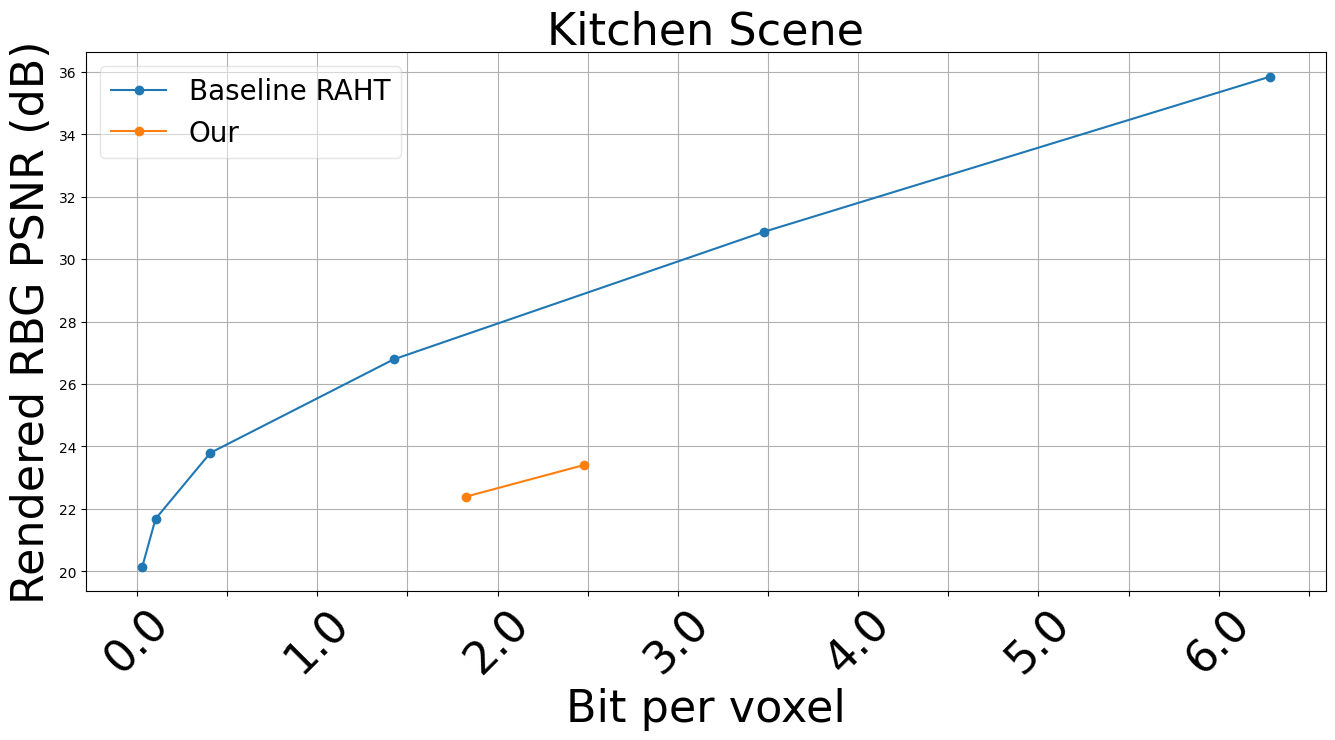

In [ ]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(16, 7))


## BASELINE 
bit_per_voxel = np.array([6.2813, 3.4782, 1.4239, 0.4072, 0.1034, 0.0297])
rendered_rgb_psnr = np.array([35.8476, 30.881 , 26.7918, 23.7951, 21.6802, 20.1446])
ax.plot(bit_per_voxel, rendered_rgb_psnr, '-o', label="Baseline RAHT")


## OUR 
# p1 23.40178466942092, 2.476877476877477
# p2 22.39191041613933, 1.8245538245538246

rendered_rgb_psnr = np.array([23.4017, 22.3919])
bit_per_voxel = np.array([2.4768, 1.8245])
ax.plot(bit_per_voxel, rendered_rgb_psnr, '-o', label="Our")

############ 
# plt.yticks(ticks=np.arange(20, 48, step=0.5), labels=["{:.1f}".format(x) if i%2==0 else "" for i, x in enumerate(np.arange(20, 48, step=0.5))], fontsize=32)
plt.xticks(ticks=np.arange(0, 7, step=0.5), labels=["{:.1f}".format(x) if i%2==0 else "" for i, x in enumerate(np.arange(0, 7, step=0.5))], rotation=45, fontsize=32)
plt.grid()
plt.legend(fancybox=True, framealpha=0.5, prop={'size': 20})
plt.xlabel('Bit per voxel', fontsize=32)
# plt.xlim((0.3, 2.8))
# plt.ylim((36, 46.0))
plt.ylabel('Rendered RBG PSNR (dB)', fontsize=32)
plt.title('Kitchen Scene', fontsize=32)

# End